<a href="https://colab.research.google.com/github/Malaika944/KNN/blob/main/Decision_Boundary_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [105]:
#our data
df = pd.DataFrame({
    'Age':    [25, 30, 45, 50, 35, 55, 40, 28, 48, 52],
    'Salary': [20000, 40000, 80000, 90000, 50000, 95000, 70000, 30000, 85000, 92000],
    'Bought': [0, 0, 1, 1, 0, 1, 1, 0, 1, 1]
})
print(df)


   Age  Salary  Bought
0   25   20000       0
1   30   40000       0
2   45   80000       1
3   50   90000       1
4   35   50000       0
5   55   95000       1
6   40   70000       1
7   28   30000       0
8   48   85000       1
9   52   92000       1


In [106]:
x= df.iloc[:,:-1].values
x
y= df.iloc[:,2].values
y

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1])

In [107]:
#Train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 0)

In [108]:
print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)


x_train shape: (8, 2)
x_test shape:  (2, 2)
y_train shape: (8,)
y_test shape:  (2,)


In [109]:
#Train
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train,y_train)


KNeighborsClassifier(n_neighbors=2)

In [110]:
#Test
y_pred=knn.predict(x_test)

In [111]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 1.0


In [112]:
x1=np.arange(x_train[:,0].min()-5,x_train[:,0].max()+5,0.5)
x1
y1= np.arange(x_train[:,1].min()-5,x_train[:,1].max()+5,5000)
y1

array([19995, 24995, 29995, 34995, 39995, 44995, 49995, 54995, 59995,
       64995, 69995, 74995, 79995, 84995, 89995, 94995])

In [113]:
#Create meshgrid so that you have prediction for all  points in space.
xx1,yy1 = np.meshgrid(x1,y1)

In [114]:
xx1.shape

(16, 80)

In [115]:
yy1.shape

(16, 80)

In [116]:
#To get prediction on each point we creatd in meshgrid
all_points = np.c_[xx1.ravel(),yy1.ravel()] # flat the array into 1D and Combine age and salary.
all_points
z=knn.predict(all_points)

In [117]:
#reshape it so that matplotlib can easily plot it.
z=z.reshape(xx1.shape)
z

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


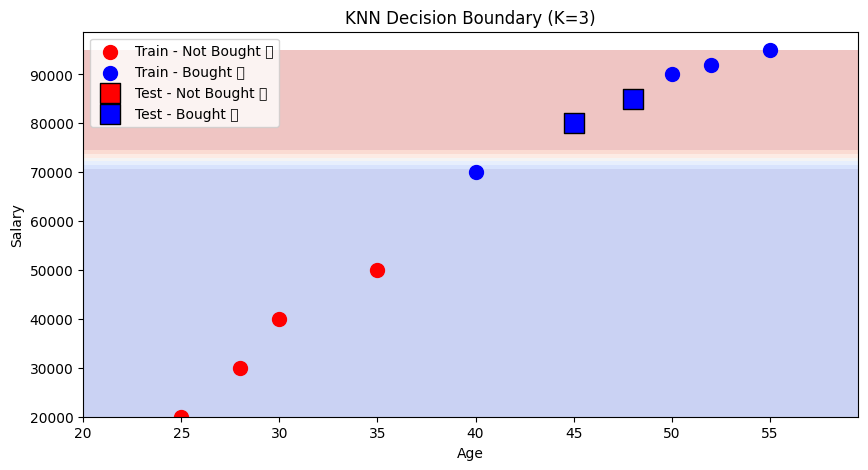

In [118]:
plt.figure(figsize=(10,5))
plt.contourf(xx1,yy1,z,alpha=0.3,cmap='coolwarm')

no_train = x_train[y_train==0] #no_train  = [[25, 20000], [30, 40000]...]   ← only Not Bought
yes_train = x_train[y_train==1]

plt.scatter(no_train[:,0],no_train[:,1],color='red',s=100,label='Train - Not Bought 🔴')
plt.scatter(yes_train[:,0],yes_train[:,1],color='blue',s=100,label='Train - Bought 🔵')

no_test  = x_test[y_test == 0]
yes_test = x_test[y_test == 1]

plt.scatter(no_test[:, 0], no_test[:, 1],
            c='red', edgecolors='black',
            s=200, marker='s',
            label='Test - Not Bought 🔴')

plt.scatter(yes_test[:, 0], yes_test[:, 1],
            c='blue', edgecolors='black',
            s=200, marker='s',
            label='Test - Bought 🔵')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title(f'KNN Decision Boundary (K=3)')
plt.legend()
plt.show()

=== Our Dataset ===
   Age  Salary  Bought
0   25   20000       0
1   30   40000       0
2   45   80000       1
3   50   90000       1
4   35   50000       0
5   55   95000       1
6   40   70000       1
7   28   30000       0
8   48   85000       1
9   52   92000       1

=== Features (x) ===
[[   25 20000]
 [   30 40000]
 [   45 80000]
 [   50 90000]
 [   35 50000]
 [   55 95000]
 [   40 70000]
 [   28 30000]
 [   48 85000]
 [   52 92000]]

=== Target (y) ===
[0 0 1 1 0 1 1 0 1 1]

=== Train Test Split ===
x_train shape: (8, 2)
x_test shape:  (2, 2)
y_train shape: (8,)
y_test shape:  (2,)

=== x_train ===
[[   35 50000]
 [   52 92000]
 [   30 40000]
 [   40 70000]
 [   28 30000]
 [   50 90000]
 [   25 20000]
 [   55 95000]]

=== x_test ===
[[   45 80000]
 [   48 85000]]

=== y_train ===
[0 1 0 1 0 1 0 1]

=== y_test ===
[1 1]

=== KNN Trained on x_train ✅ ===

=== Predictions vs Actual ===
   Actual  Predicted
0       1          1
1       1          1

=== Accuracy: 100.00% ===

=== 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


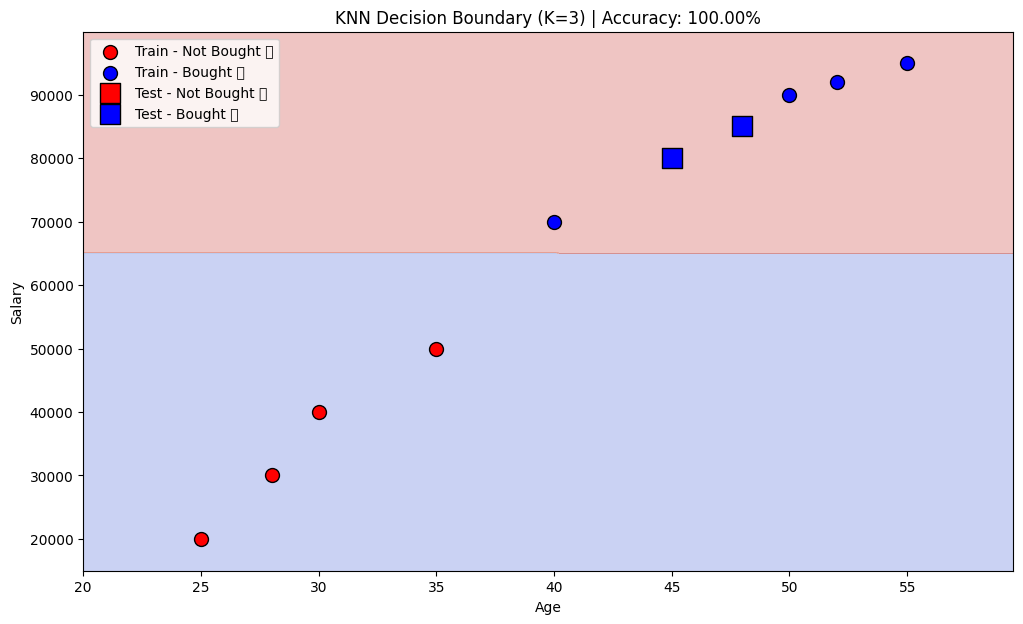

In [69]:
#Another example
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =====================
# Step 1: Create DataFrame
# =====================
data = {
    'Age':    [25, 30, 45, 50, 35, 55, 40, 28, 48, 52],
    'Salary': [20000, 40000, 80000, 90000, 50000, 95000, 70000, 30000, 85000, 92000],
    'Bought': [0, 0, 1, 1, 0, 1, 1, 0, 1, 1]
}

df = pd.DataFrame(data)
print("=== Our Dataset ===")
print(df)
print()

# =====================
# Step 2: Separate Features and Target
# =====================
x = df[['Age', 'Salary']].values
y = df['Bought'].values

print("=== Features (x) ===")
print(x)
print()
print("=== Target (y) ===")
print(y)
print()

# =====================
# Step 3: Train Test Split
# =====================
x_train, x_test, y_train, y_test = train_test_split(
                                    x, y,
                                    test_size=0.2,
                                    random_state=0)

print("=== Train Test Split ===")
print("x_train shape:", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)
print()

print("=== x_train ===")
print(x_train)
print()
print("=== x_test ===")
print(x_test)
print()
print("=== y_train ===")
print(y_train)
print()
print("=== y_test ===")
print(y_test)
print()

# =====================
# Step 4: Train KNN on x_train
# =====================
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
print("=== KNN Trained on x_train ✅ ===")
print()

# =====================
# Step 5: Predict on x_test
# =====================
y_pred = knn.predict(x_test)

print("=== Predictions vs Actual ===")
results = pd.DataFrame({
    'Actual':     y_test,
    'Predicted':  y_pred
})
print(results)
print()

# =====================
# Step 6: Accuracy
# =====================
accuracy = accuracy_score(y_test, y_pred)
print(f"=== Accuracy: {accuracy * 100:.2f}% ===")
print()

# =====================
# Step 7: Meshgrid
# =====================
x1 = np.arange(x_train[:, 0].min() - 5,
                x_train[:, 0].max() + 5, 0.5)       # age range from x_train

x2 = np.arange(x_train[:, 1].min() - 5000,
                x_train[:, 1].max() + 5000, 100)     # salary range from x_train

xx1, xx2 = np.meshgrid(x1, x2)

print("=== Meshgrid Created ===")
print("Total points to predict:", xx1.ravel().shape[0])
print()

# =====================
# Step 8: Predict Every Point on Grid
# =====================
all_points = np.c_[xx1.ravel(), xx2.ravel()]
Z = knn.predict(all_points)
Z = Z.reshape(xx1.shape)
print("=== All Grid Points Predicted ✅ ===")
print()

# =====================
# Step 9: Draw the Graph
# =====================
plt.figure(figsize=(12, 7))

# color the background
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')

# plot x_train points
no_train = x_train[y_train == 0]
yes_train = x_train[y_train == 1]

plt.scatter(no_train[:, 0], no_train[:, 1],
            c='red', edgecolors='black',
            s=100, label='Train - Not Bought 🔴')

plt.scatter(yes_train[:, 0], yes_train[:, 1],
            c='blue', edgecolors='black',
            s=100, label='Train - Bought 🔵')

# plot x_test points
no_test = x_test[y_test == 0]
yes_test = x_test[y_test == 1]

plt.scatter(no_test[:, 0], no_test[:, 1],
            c='red', edgecolors='black',
            s=200, marker='s',
            label='Test - Not Bought 🔴')

plt.scatter(yes_test[:, 0], yes_test[:, 1],
            c='blue', edgecolors='black',
            s=200, marker='s',
            label='Test - Bought 🔵')

plt.xlabel('Age')
plt.ylabel('Salary')
plt.title(f'KNN Decision Boundary (K=3) | Accuracy: {accuracy * 100:.2f}%')
plt.legend()
plt.show()